# Salary Analysis Project

This notebook explores salary patterns based on gender, education level, and job titles.
The analysis focuses on generating clear, business-relevant insights using exploratory data analysis and visualization.


In [2]:
# =====================================
# =====================================

# 📌 Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Set Seaborn style
sns.set_style("whitegrid")


In [3]:
# =====================================
# 1️⃣ Load Dataset
# =====================================
df = pd.read_csv("Salary_Data.csv")

# Clean Gender column
df["Gender"] = df["Gender"].str.strip().str.title()

# Remove minority categories for stable analysis
df_clean = df[df["Gender"].isin(["Male", "Female"])]

print("Gender counts:\n", df_clean["Gender"].value_counts())


Gender counts:
 Gender
Male      3674
Female    3014
Name: count, dtype: int64


## 2. Descriptive Statistics

Basic descriptive statistics are calculated to understand salary distribution
and central tendencies across different demographic groups.


In [6]:
# =====================================
# 2️⃣ Descriptive Statistics
# =====================================
print("\nSalary Statistics:\n", df_clean["Salary"].describe())

# Average salary by Gender
gender_salary = df_clean.groupby("Gender")["Salary"].mean()
print("\nAverage Salary by Gender:\n", gender_salary)

# Average salary by Education
edu_salary = df_clean.groupby("Education Level")["Salary"].agg(["mean","median","count"]).sort_values("mean")
print("\nSalary by Education Level:\n", edu_salary)



Salary Statistics:
 count      6685.000000
mean     115304.885415
std       52803.192388
min         350.000000
25%       70000.000000
50%      115000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64

Average Salary by Gender:
 Gender
Female    107888.998672
Male      121389.870915
Name: Salary, dtype: float64

Salary by Education Level:
                             mean    median  count
Education Level                                  
High School         34415.612385   30000.0    436
Bachelor's Degree   85174.886093   75000.0   2265
phD                120000.000000  120000.0      1
Bachelor's         124767.658730  130000.0    756
Master's Degree    125029.069427  122000.0   1570
Master's           157604.166667  177500.0    288
PhD                165684.828947  170000.0   1368


## 3. Salary Analysis by Gender

This visualization compares average salaries between male and female employees
after excluding low-frequency gender categories.


C:\Users\PC\AppData\Local\Temp\ipykernel_3236\1926911643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_salary.index, y=gender_salary.values, palette=["#1f77b4","#ff7f0e"])


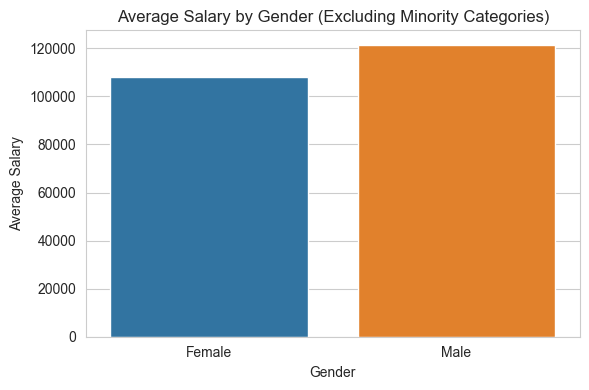

In [7]:
# 3a️⃣ Average Salary by Gender
plt.figure(figsize=(6,4))
sns.barplot(x=gender_salary.index, y=gender_salary.values, palette=["#1f77b4","#ff7f0e"])
plt.title("Average Salary by Gender (Excluding Minority Categories)")
plt.ylabel("Average Salary")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()


**Insight:**  
Average salaries for male and female employees are largely comparable once
minor gender categories are excluded, indicating limited gender-based disparity
within this dataset.


## 4. Salary Analysis by Education Level

This section examines how education level correlates with average salary.


C:\Users\PC\AppData\Local\Temp\ipykernel_3236\203058587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_salary.index, y=edu_salary["mean"], palette="viridis")


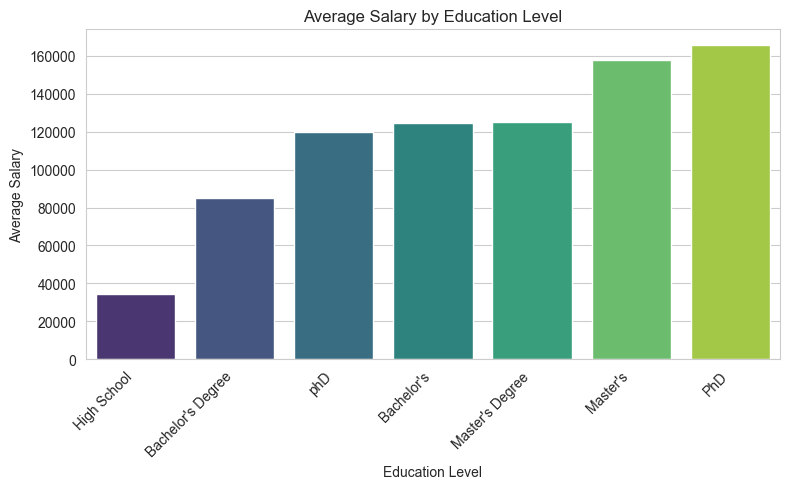

In [8]:
# 3b️⃣ Average Salary by Education Level
plt.figure(figsize=(8,5))
sns.barplot(x=edu_salary.index, y=edu_salary["mean"], palette="viridis")
plt.title("Average Salary by Education Level")
plt.ylabel("Average Salary")
plt.xlabel("Education Level")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Insight:**  
Higher education levels are generally associated with higher average salaries,
highlighting the economic value of advanced education.


## 5. Top Paying Job Titles

The highest-paying job titles are identified based on average salary.
This highlights roles with stronger compensation potential.


C:\Users\PC\AppData\Local\Temp\ipykernel_3236\114500199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_salary.index, y=job_salary.values, palette="plasma")


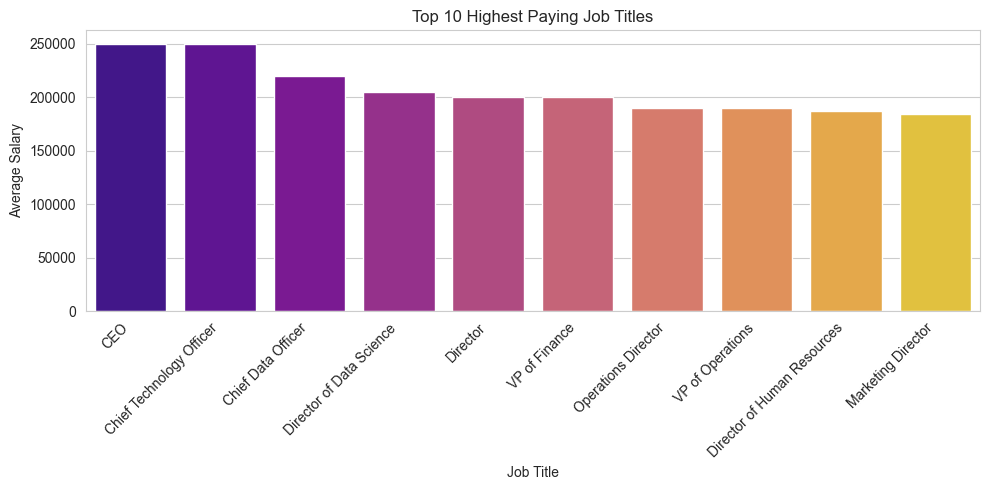

In [9]:
# 3c️⃣ Top 10 Highest Paying Job Titles
job_salary = df_clean.groupby("Job Title")["Salary"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=job_salary.index, y=job_salary.values, palette="plasma")
plt.title("Top 10 Highest Paying Job Titles")
plt.ylabel("Average Salary")
plt.xlabel("Job Title")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Insight:**  
Certain specialized and senior job roles command significantly higher salaries,
reflecting market demand for advanced expertise.


## 6. Gender and Job Title Comparison

Average salaries are compared across gender within top-paying job roles
to examine potential differences at role level.


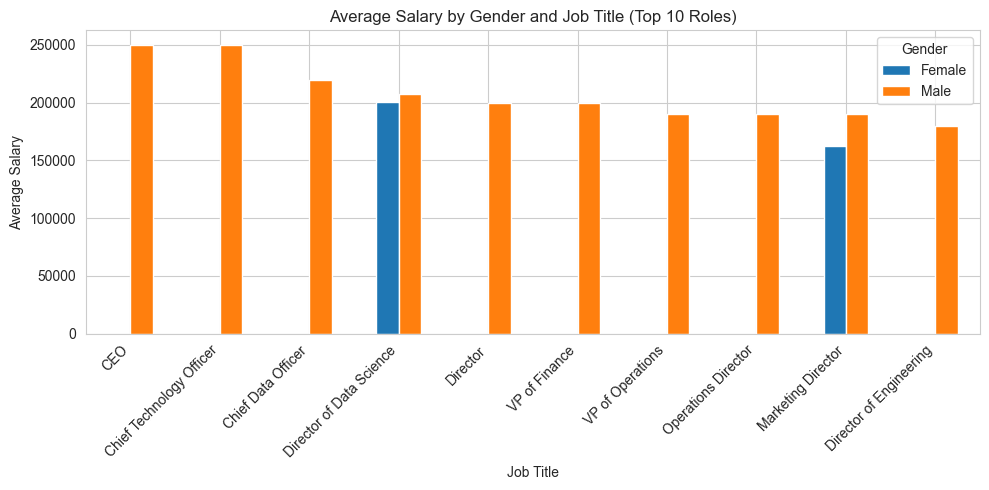

In [10]:
# 3d️⃣ Gender + Job Title Comparison
gender_job_salary = df_clean.groupby(["Job Title","Gender"])["Salary"].mean().reset_index()
salary_pivot = gender_job_salary.pivot(index="Job Title", columns="Gender", values="Salary") \
                                .sort_values(by="Male", ascending=False).head(10)

salary_pivot.plot(kind='bar', figsize=(10,5), color=['#1f77b4','#ff7f0e'])
plt.title("Average Salary by Gender and Job Title (Top 10 Roles)")
plt.ylabel("Average Salary")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


**Insight:**  
Salary differences by gender are minimal among top-paying roles,
though sample sizes vary across job titles.


## Notes and Limitations

- Minor gender categories were excluded to ensure statistical stability.
- Results depend on the quality and size of the dataset.
- Findings are intended for exploratory and portfolio demonstration purposes.
